In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

IMPORTING DATASETS

In [2]:
data = 'D:/Online course/Python/Project/Datasets/pbmc33k_filtered_gene_bc_matrices/filtered_gene_bc_matrices/hg19/'

In [3]:
adata = sc.read_10x_mtx(
    data,
    var_names = 'gene_symbols',
    cache = True
)
adata.var_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 33148 × 32738
    var: 'gene_ids'


SCALING \ NORMALIZING DATA

In [4]:
sc.pp.highly_variable_genes(
    adata,
    flavor = 'seurat_v3',
    n_top_genes = 2000
)

In [5]:
sc.pp.normalize_total(adata, target_sum = 10000)

In [6]:
sc.pp.log1p(adata)

In [7]:
adata = adata[:, adata.var.highly_variable]

In [8]:
print(adata)

View of AnnData object with n_obs × n_vars = 33148 × 2000
    var: 'gene_ids', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p'


In [9]:
adata.raw = adata

In [10]:
sc.pp.scale(adata,max_value = 10)

c:\Users\aksh3\anaconda3\envs\tf-env\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


PERFORMING PCA

In [11]:
sc.tl.pca(adata, svd_solver = 'arpack')

In [12]:
print(adata)

AnnData object with n_obs × n_vars = 33148 × 2000
    var: 'gene_ids', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'


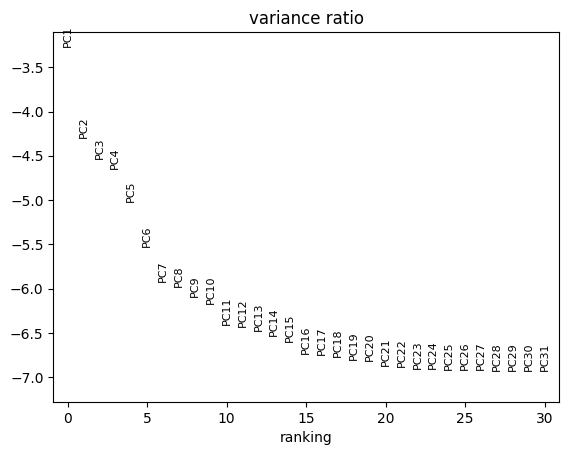

In [13]:
sc.pl.pca_variance_ratio(adata, log = 1)

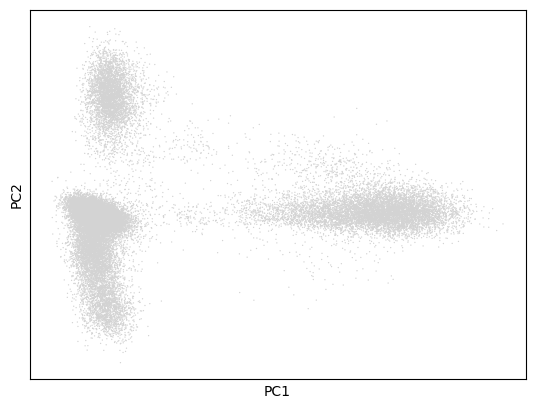

In [14]:
sc.pl.pca(adata)

CLUSTERING DATA BASED ON GENE EXPRESSION

In [15]:
sc.pp.neighbors(
    adata,
    n_neighbors = 10,
    n_pcs = 15
)

In [16]:
sc.tl.leiden(adata, resolution = 0.5)

C:\Users\aksh3\AppData\Local\Temp\ipykernel_24672\3246266323.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = 0.5)


In [17]:
sc.tl.umap(adata)

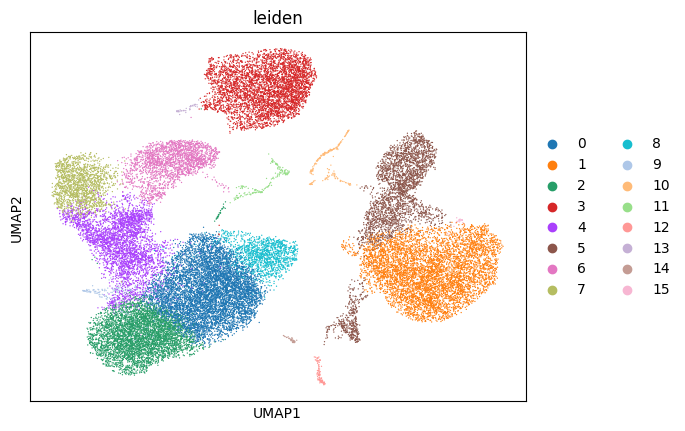

In [18]:
sc.pl.umap(adata, color = ['leiden'])

FINDING DOMINANT GENE OF EACH CLUSTER

In [19]:
sc.tl.rank_genes_groups(adata, 'leiden', method = 'wilcoxon')

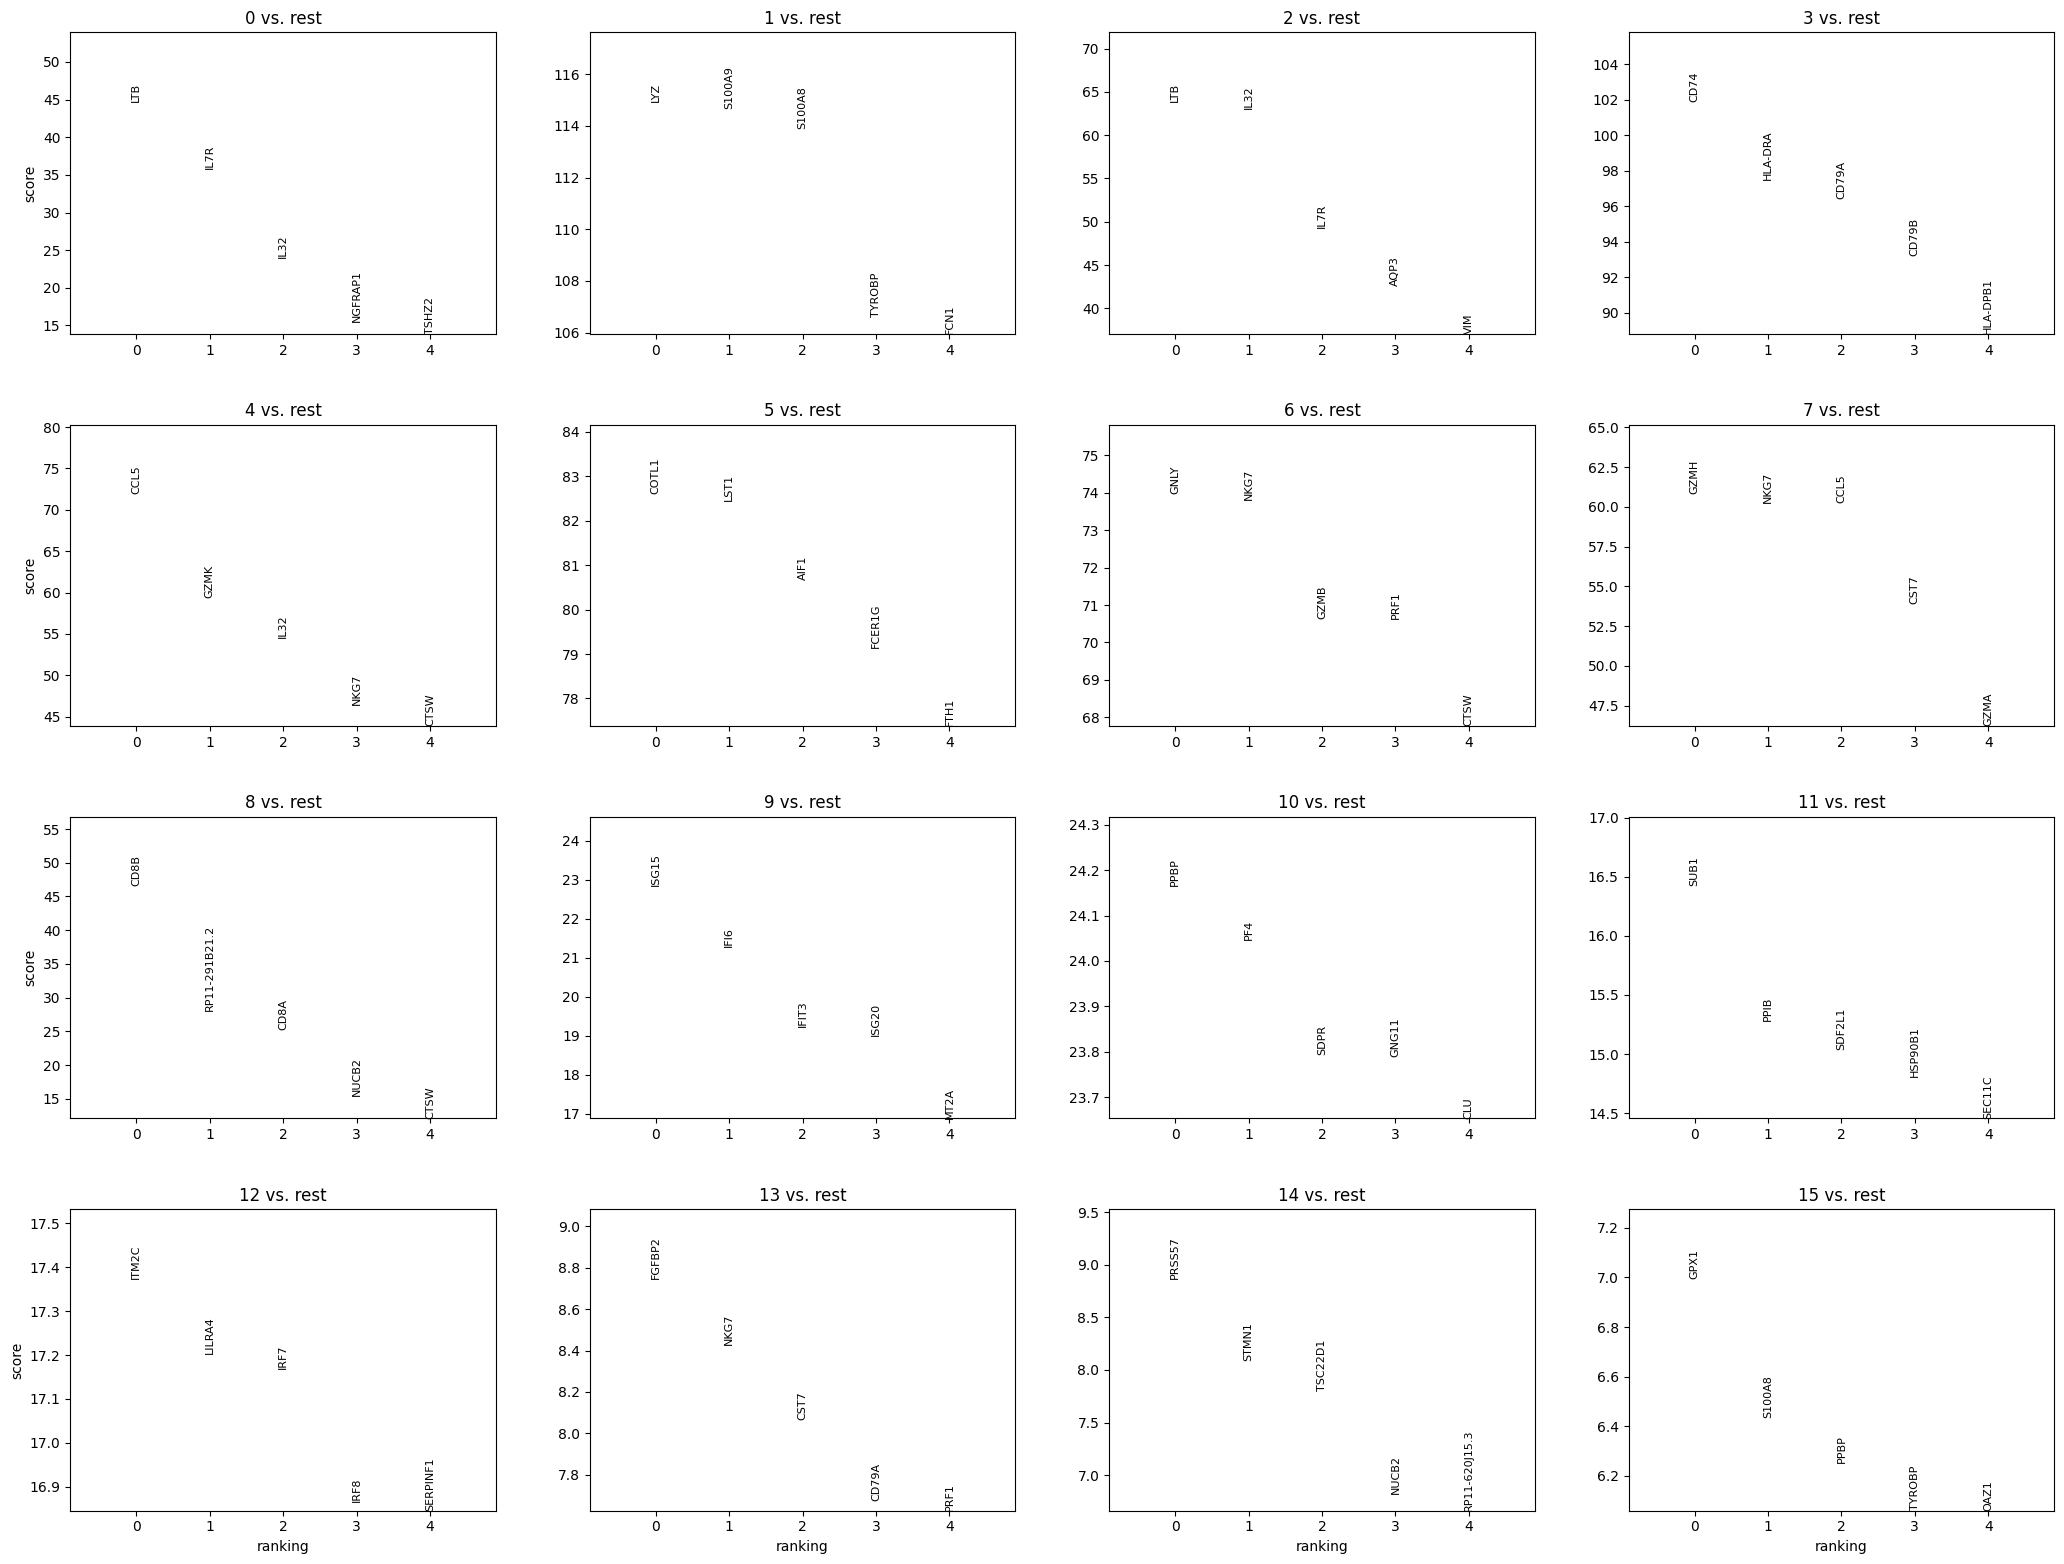

In [20]:
sc.pl.rank_genes_groups(adata, n_genes = 5, sharey = 0)

IDENTIFYING CELL TYPE OF CLUSTERS

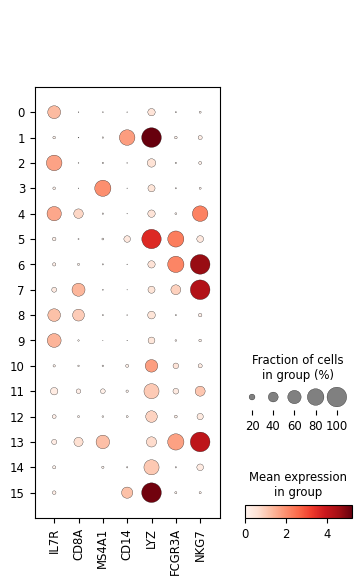

In [21]:
marker_genes = ['IL7R', 'CD8A', 'MS4A1', 'CD14', 'LYZ', 'FCGR3A', 'NKG7']
sc.pl.dotplot(adata, marker_genes, groupby='leiden')

In [22]:
clust_annot = {
    '0': 'CD4 T-cells',
    '1': 'CD14 Monocytes',
    '2': 'CD4 T-cells',
    '3': 'B-Cells',
    '4': 'CD4 T-cells',
    '5': 'FCGR3A monocytes',
    '6': 'NK cells',
    '7': 'CD8 T-cells',
    '8': 'CD8 T-cells',
    '9': 'CD4 T-cells',
    '10': 'NA',
    '11': 'NA',
    '12': 'NA',
    '13': 'NA',
    '14': 'NA',
    '15': 'CD14 Monocytes'
}
adata.obs['cell_type'] = adata.obs['leiden'].map(clust_annot).astype('category')

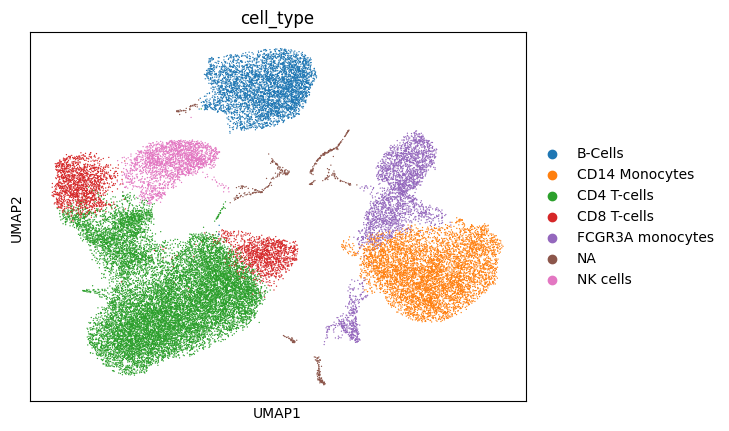

In [23]:
sc.pl.umap(adata, color = 'cell_type')

PREPARING DATA FOR SUPERVISED LEARNING

In [24]:
adata_clean = adata[adata.obs['cell_type'] != 'NA'].copy()
adata_clean.obs['cell_type'] = adata_clean.obs['cell_type'].cat.remove_unused_categories()

In [25]:
print(adata_clean.obs)

                 leiden         cell_type
AAACATTGACGACT-1      0       CD4 T-cells
AAACATTGACGGGA-1      6          NK cells
AAACATTGCCGCTT-1      1    CD14 Monocytes
AAACATTGCTCATT-1      4       CD4 T-cells
AAACCGTGCCCTCA-1      3           B-Cells
...                 ...               ...
TTTGCATGCACTAG-6      7       CD8 T-cells
TTTGCATGCCGAAT-6      4       CD4 T-cells
TTTGCATGGAGGTG-6      5  FCGR3A monocytes
TTTGCATGGATAAG-6      4       CD4 T-cells
TTTGCATGGGCATT-6      4       CD4 T-cells

[32610 rows x 2 columns]


In [26]:
x = pd.DataFrame(
    adata_clean.X,
    columns = adata_clean.var_names,
    index = adata_clean.obs_names
)
y = adata_clean.obs['cell_type']

In [27]:
x

,HES4,ISG15,C1orf159,TNFRSF18,TNFRSF4,PEX10,SMIM1,CEP104,DFFB,C1orf174,...,MORC3,WRB,BACE2,PDE9A,CSTB,C21orf67,ADARB1,SPATC1L,S100B,MT-ND6
AAACATTGACGACT-1,-0.215565,-0.767908,-0.072434,-0.185552,-0.223976,-0.11619,-0.06787,-0.137333,-0.093837,-0.228192,...,-0.169069,-0.151968,-0.103469,-0.076603,-0.690265,-0.02221,-0.117498,-0.178704,-0.162709,-0.264036
AAACATTGACGGGA-1,-0.215565,-0.767908,-0.072434,-0.185552,-0.223976,-0.11619,-0.06787,-0.137333,-0.093837,5.043938,...,-0.169069,-0.151968,-0.103469,-0.076603,-0.690265,-0.02221,-0.117498,-0.178704,-0.162709,-0.264036
AAACATTGCCGCTT-1,-0.215565,-0.767908,-0.072434,-0.185552,-0.223976,-0.11619,-0.06787,-0.137333,-0.093837,-0.228192,...,-0.169069,-0.151968,-0.103469,-0.076603,-0.690265,-0.02221,-0.117498,-0.178704,-0.162709,-0.264036
AAACATTGCTCATT-1,-0.215565,-0.767908,-0.072434,-0.185552,-0.223976,-0.11619,-0.06787,-0.137333,-0.093837,-0.228192,...,-0.169069,-0.151968,-0.103469,-0.076603,-0.690265,-0.02221,-0.117498,-0.178704,-0.162709,3.858575
AAACCGTGCCCTCA-1,-0.215565,-0.767908,-0.072434,-0.185552,-0.223976,-0.11619,-0.06787,-0.137333,-0.093837,-0.228192,...,-0.169069,-0.151968,-0.103469,-0.076603,-0.690265,-0.02221,-0.117498,-0.178704,-0.162709,-0.264036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGCATGCACTAG-6,-0.215565,-0.767908,-0.072434,-0.185552,-0.223976,-0.11619,-0.06787,-0.137333,-0.093837,-0.228192,...,-0.169069,-0.151968,-0.103469,-0.076603,-0.690265,-0.02221,-0.117498,-0.178704,-0.162709,-0.264036
TTTGCATGCCGAAT-6,-0.215565,1.386812,-0.072434,-0.185552,-0.223976,-0.11619,-0.06787,-0.137333,-0.093837,-0.228192,...,-0.169069,-0.151968,-0.103469,-0.076603,-0.690265,-0.02221,-0.117498,-0.178704,-0.162709,-0.264036
TTTGCATGGAGGTG-6,3.597328,0.459955,-0.072434,-0.185552,-0.223976,-0.11619,-0.06787,-0.137333,-0.093837,-0.228192,...,-0.169069,-0.151968,-0.103469,-0.076603,1.973290,-0.02221,-0.117498,-0.178704,-0.162709,-0.264036
TTTGCATGGATAAG-6,-0.215565,1.419624,-0.072434,-0.185552,-0.223976,-0.11619,-0.06787,-0.137333,-0.093837,-0.228192,...,-0.169069,-0.151968,-0.103469,-0.076603,-0.690265,-0.02221,-0.117498,-0.178704,-0.162709,-0.264036


In [28]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

SUPERVISED CLASSIFIER TRAINING

In [29]:
# Splitting Data for training and testing.

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 42)

LOGISTIC REGRESSION MODEL

In [30]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(n_jobs = -1)
lr.fit(x_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [31]:
lr_pred = lr.predict(x_test)

In [32]:
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1248
           1       0.98      0.97      0.97      1626
           2       0.96      0.96      0.96      4489
           3       0.79      0.79      0.79       878
           4       0.95      0.96      0.96       935
           5       0.97      0.96      0.97       607

    accuracy                           0.95      9783
   macro avg       0.94      0.94      0.94      9783
weighted avg       0.95      0.95      0.95      9783



DECISION TREE CLASSIFIER

In [33]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth = None)
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
dt_pred = dt.predict(x_test)

In [35]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1248
           1       0.93      0.94      0.93      1626
           2       0.95      0.96      0.95      4489
           3       0.76      0.74      0.75       878
           4       0.89      0.87      0.88       935
           5       0.92      0.91      0.91       607

    accuracy                           0.93      9783
   macro avg       0.91      0.90      0.90      9783
weighted avg       0.93      0.93      0.93      9783



In [ ]:
# Deleting unused variables
del data
del adata

In [ ]:
# Cleaning Garbage
import gc
gc.collect()

589

XGBOOST CLASSIFIER

In [38]:
import xgboost as xgb
import cupy as cp
xg = xgb.XGBClassifier(
n_estimators=10000, 
random_state= 42, 
tree_method = "hist", 
device = 'cuda', 
max_depth = None, 
early_stopping_rounds = 50,
learning_rate = 0.01
)

In [39]:
x_test_gpu = cp.array(x_test)
e_set = [(x_test, y_test)]

In [40]:
xg.fit(x_train, y_train, eval_set = e_set, verbose = 0)
xg_pred = xg.predict(x_test_gpu)

In [41]:
print(classification_report(y_test, xg_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1248
           1       0.97      0.98      0.97      1626
           2       0.97      0.98      0.98      4489
           3       0.92      0.86      0.88       878
           4       0.96      0.94      0.95       935
           5       0.96      0.98      0.97       607

    accuracy                           0.97      9783
   macro avg       0.96      0.96      0.96      9783
weighted avg       0.97      0.97      0.97      9783



In [45]:
print(xg.best_iteration)

2099


RANDOM FOREST CLASSIFIER

In [48]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_jobs = -1)

In [49]:
rfc.fit(x_train, y_train)
rfc_pred = rfc.predict(x_test)

In [50]:
print(classification_report(rfc_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1248
           1       0.99      0.94      0.96      1706
           2       0.99      0.95      0.97      4702
           3       0.71      0.94      0.81       664
           4       0.89      0.98      0.93       855
           5       0.97      0.97      0.97       608

    accuracy                           0.96      9783
   macro avg       0.93      0.96      0.94      9783
weighted avg       0.96      0.96      0.96      9783

